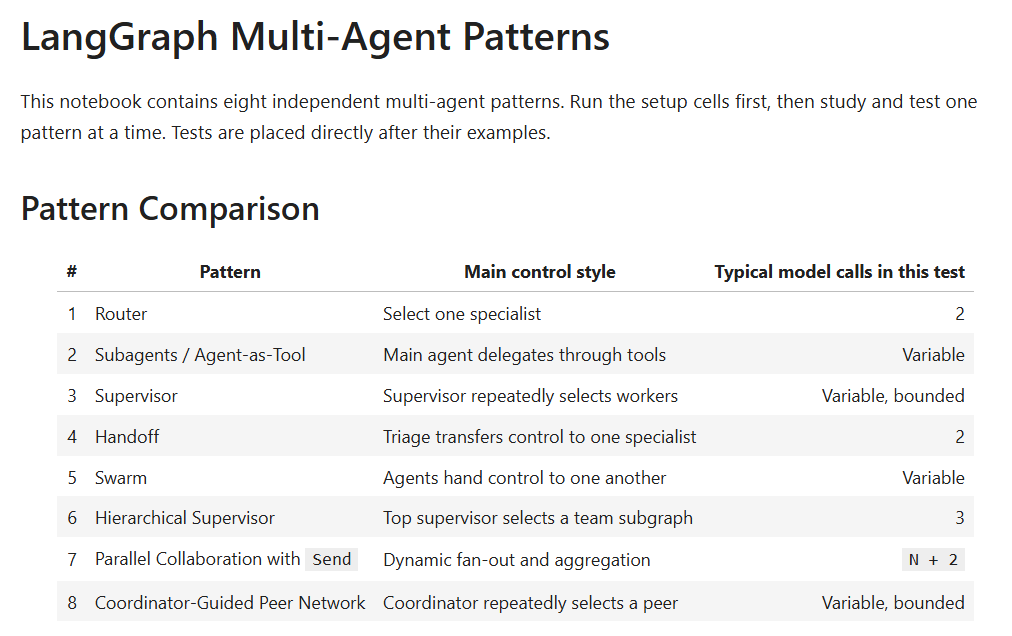

In [41]:
#ALL Import Statments 

import os
from typing import (
    TypedDict,
    Literal,
    Annotated,
)

import operator

from dotenv import load_dotenv
from pydantic import BaseModel

from langchain_openai import ChatOpenAI
from langchain_core.messages import (
    HumanMessage,
    AIMessage,
)
from langchain_core.tools import tool
from langchain.agents import create_agent

from langgraph.graph import (
    StateGraph,
    START,
    END,
    MessagesState,
)
from langgraph.types import (
    Command,
    Send,
)
from langgraph.checkpoint.memory import InMemorySaver
from langchain_groq import ChatGroq

In [42]:
load_dotenv()
# OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY")

True

In [43]:
model = ChatOpenAI(
    model="gpt-4.1-mini",
    temperature=0
  
)



In [44]:
def show_graph(compiled_graph):
    """Print the generated graph as Mermaid text."""
    print(compiled_graph.get_graph().draw_mermaid())

## 1. Router Multi Agent
- This is Partial Agentic System Not Fully MultiAgentic system.
- Router Based LLM workflow with Specialized LLM Nodes.

**State and Routing Scehma**

In [45]:
class RouterDecision(BaseModel):
    route: Literal[ "technical",
        "billing",
        "general",]

In [46]:
router_model=model.with_structured_output(RouterDecision)

In [47]:
router_model.invoke("I have refund issue with my last purchase. Can you help me?")

RouterDecision(route='billing')

In [48]:
class RouterState(TypedDict):
    query:str
    route:str
    response:str

In [49]:
def router_node(state:RouterState):
    decision=router_model.invoke(
              f"""
Route the following user query to exactly one specialist.

Available specialists:
- technical
- billing
- general
User query: {state['query']}"""
    )
    return{
        "route":decision.route,
        
    }

In [50]:
def technical_agent(state:RouterState):
    response=model.invoke(
        f"""You are a technical support specialist.
        Answer the following user query in a helpful and concise manner.
        User query: {state['query']}"""
    )
    return{
        "response":response.content
    }

In [51]:
def billing_Agent(state:RouterState):
    response=model.invoke(
        f"""You are a billing support specialist.
        Answer the following user query in a helpful and concise manner.
        User query: {state['query']}"""
    )
    return{
        "response":response.content
    }

In [52]:
def general_agent(state:RouterState):
    response=model.invoke(
        f"""You are a general support specialist.
        Answer the following user query in a helpful and concise manner.
        User query: {state['query']}"""
    )
    return{
        "response":response.content
    }

In [53]:
def router_to_Specialist(state:RouterState):
    return state['route']

In [72]:
def build_router_multi_agent():
    builder = StateGraph(RouterState)
    
    builder.add_node(
        "router",
        router_node,
    )

    builder.add_node(
        "technical",
        technical_agent,
    )

    builder.add_node(
        "billing",
        billing_Agent,
    )

    builder.add_node(
        "general",
        general_agent,
    )
    builder.add_edge(START, "router")
    builder.add_conditional_edges(
        "router",
        router_to_Specialist,
        {
            "technical": "technical",
            "billing": "billing",
            "general": "general"
        }
    )
    builder.add_edge("technical", END)
    builder.add_edge("billing", END)
    builder.add_edge("general", END)   

    return builder.compile()

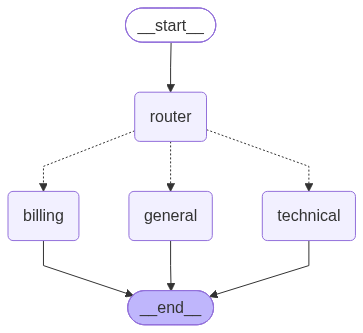

In [74]:
build_router_multi_agent()

In [73]:
router_graph = build_router_multi_agent()
show_graph(router_graph)

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	router(router)
	technical(technical)
	billing(billing)
	general(general)
	__end__([<p>__end__</p>]):::last
	__start__ --> router;
	router -.-> billing;
	router -.-> general;
	router -.-> technical;
	billing --> __end__;
	general --> __end__;
	technical --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



***Test The Graph***

In [ ]:
def run_routerbased_MultiAgent(inputquery:str):
     graph = (build_router_multi_agent())

     result = graph.invoke(
           {
            "query":inputquery,
            "route": "",
            "response": "",
        }
     )
     print(
        "Selected Agent:",
        result["route"],
    )
     print(
        "\nResponse:\n",
        result["response"],
    )
     return result

In [ ]:
router_result = run_routerbased_MultiAgent("My subscription payment was charged twice.")


TypeError: run_routerbased_MultiAgent() missing 1 required positional argument: 'query'